# Movie Sentiment Analyzer

In [ ]:
%pip install pandas numpy scikit-learn matplotlib seaborn nltk jupyter joblib


In [33]:

from pathlib import Path
import re
import string
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk 

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import joblib

%matplotlib inline

sns.set_style("whitegrid")

## NLTK Stopwords

This downloads the stopwords list the first time you run it.

In [35]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\darsh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [36]:
dataset_path = Path("data") / "IMDB Dataset.csv"
print("Dataset path:", dataset_path)
print("Dataset exists:", dataset_path.exists())

Dataset path: data\IMDB Dataset.csv
Dataset exists: True


In [37]:
if not dataset_path.exists():
    raise FileNotFoundError("Please place 'IMDB Dataset.csv' inside the data folder before running this cell.")
df = pd.read_csv(dataset_path)
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [38]:
print("Rows and columns:", df.shape)
print("Columns:", df.columns.tolist())

Rows and columns: (50000, 2)
Columns: ['review', 'sentiment']


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


In [40]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [41]:
df["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

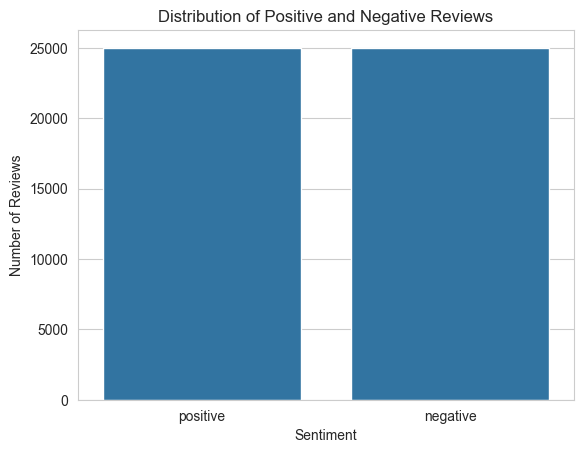

In [42]:
sns.countplot(data=df, x="sentiment")
plt.title("Distribution of Positive and Negative Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

In [ ]:
label_mapping = {"negative": 0, "positive": 1}
df["sentiment_number"] = df["sentiment"].map(label_mapping)
df.head()

,review,sentiment,sentiment_number
0,One of the other reviewers has mentioned that ...,positive,1
1,A wonderful little production. <br /><br />The...,positive,1
2,I thought this was a wonderful way to spend ti...,positive,1
3,Basically there's a family where a little boy ...,negative,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1


In [ ]:
stop_words = set(stopwords.words("english"))
negation_words = {"no", "not", "nor", "never"}
stop_words = stop_words - negation_words
print("Number of stopwords:", len(stop_words))

Number of stopwords: 195


In [45]:

def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\d+", " ", text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    cleaned_text = " ".join(words)
    return cleaned_text

In [46]:
df["clean_review"] = df["review"].apply(clean_text)
df[["review", "clean_review", "sentiment"]].head()

,review,clean_review,sentiment
0,One of the other reviewers has mentioned that ...,one reviewers mentioned watching oz episode yo...,positive
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...,positive
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...,positive
3,Basically there's a family where a little boy ...,basically theres family little boy jake thinks...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...,positive


In [54]:
print("Original review:\n")
print(df.loc[0, "review"])
print("\n" + "-" * 80 + "\n")
print("Cleaned review:\n")
print(df.loc[0, "clean_review"])

Original review:

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show

In [ ]:
df["sentiment_number"] = df["sentiment"].map({
    "negative": 0,
    "positive": 1
})
df[["sentiment", "sentiment_number"]].head()


,sentiment,sentiment_number
0,positive,1
1,positive,1
2,positive,1
3,negative,0
4,positive,1


In [57]:
X = df["clean_review"]
y = df["sentiment_number"]
X_train, X_test, y_train, y_test = train_test_split(
    X,                 
    y,                 
    test_size=0.2,     # Use 20 percent of the data for testing.
    random_state=42,   
    stratify=y        
)
print("Training reviews:", X_train.shape[0])
print("Testing reviews:", X_test.shape[0])

Training reviews: 40000
Testing reviews: 10000


In [58]:
tfidf = TfidfVectorizer(
    max_features=10000, 
    ngram_range=(1, 2)  
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (40000, 10000)
Testing TF-IDF shape: (10000, 10000)


In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)
print("Model training completed.")

Model training completed.


In [59]:
y_pred = model.predict(X_test_tfidf)
print("First 10 predictions:", y_pred[:10])

First 10 predictions: [0 1 1 0 0 0 0 0 0 0]


In [60]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Accuracy percentage:", round(accuracy * 100, 2), "%")

Accuracy: 0.8991
Accuracy percentage: 89.91 %


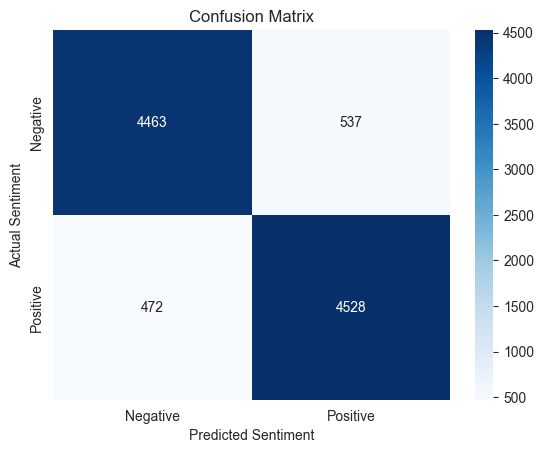

In [ ]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,                             
    annot=True,                      
    fmt="d",                        
    cmap="Blues",                   
    xticklabels=["Negative", "Positive"], # Labels for predicted classes.
    yticklabels=["Negative", "Positive"]  # Labels for actual classes.
)
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.title("Confusion Matrix")
plt.savefig(Path("outputs") / "confusion_matrix.png", bbox_inches="tight")
plt.show()

In [62]:
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

              precision    recall  f1-score   support

    Negative       0.90      0.89      0.90      5000
    Positive       0.89      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [63]:
def predict_sentiment(review):
    cleaned_review = clean_text(review)
    review_tfidf = tfidf.transform([cleaned_review])
    prediction = model.predict(review_tfidf)[0]
    probabilities = model.predict_proba(review_tfidf)[0]
    if prediction == 1:
        sentiment = "Positive"
        confidence = probabilities[1]
    else:
        sentiment = "Negative"
        confidence = probabilities[0]
    print("Review:", review)
    print("Cleaned review:", cleaned_review)
    print("Predicted sentiment:", sentiment)
    print("Confidence:", round(confidence * 100, 2), "%")

In [64]:
my_review = "The movie was amazing, emotional, and beautifully acted."
predict_sentiment(my_review)

Review: The movie was amazing, emotional, and beautifully acted.
Cleaned review: movie amazing emotional beautifully acted
Predicted sentiment: Positive
Confidence: 98.23 %


In [65]:
my_review = "The film was boring, slow, and a complete waste of time."
predict_sentiment(my_review)

Review: The film was boring, slow, and a complete waste of time.
Cleaned review: film boring slow complete waste time
Predicted sentiment: Negative
Confidence: 99.86 %


In [66]:
joblib.dump(model, Path("models") / "sentiment_model.pkl")
joblib.dump(tfidf, Path("models") / "tfidf_vectorizer.pkl")
print("Model and vectorizer saved successfully.")

Model and vectorizer saved successfully.
